# Task 4: Full EDA Report on JSONPlaceholder Posts

This notebook fetches real post data from a public API, cleans it, runs a full EDA checklist, creates charts, and prints a short report.

## 1) Import libraries

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

# Keep the charts readable and consistent.
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

## 2) Fetch data from API

In [20]:
url = "https://jsonplaceholder.typicode.com/posts"

response = requests.get(url, timeout=30)
response.raise_for_status()
data = response.json()
df = pd.DataFrame(data)

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


## 3) Clean data

In [21]:
df = df[['userId', 'id', 'title', 'body']]

df = df.drop_duplicates()
df = df.dropna()

df['title'] = (
    df['title']
    .astype(str)
    .str.strip()
    .str.title()
)

df['body'] = (
    df['body']
    .astype(str)
    .str.strip()
)

df['title_length'] = df['title'].str.len()
df['body_length'] = df['body'].str.len()
df['word_count'] = df['title'].str.split().str.len()

df.to_csv('clean_posts.csv', index=False)

print("Data Cleaned Successfully")

Data Cleaned Successfully


## 4) EDA checklist

In [6]:
print("\nDataset Shape:")
print(df.shape)

print("\nDataset Info:")
print(df.info())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDescriptive Statistics:")
print(df.describe())

print("\nPosts Per User:")
print(df['userId'].value_counts())


Dataset Shape:
(100, 7)

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   userId        100 non-null    int64
 1   id            100 non-null    int64
 2   title         100 non-null    str  
 3   body          100 non-null    str  
 4   title_length  100 non-null    int64
 5   body_length   100 non-null    int64
 6   word_count    100 non-null    int64
dtypes: int64(5), str(2)
memory usage: 5.6 KB
None

Data Types:
userId          int64
id              int64
title             str
body              str
title_length    int64
body_length     int64
word_count      int64
dtype: object

Missing Values:
userId          0
id              0
title           0
body            0
title_length    0
body_length     0
word_count      0
dtype: int64

Descriptive Statistics:
           userId          id  title_length  body_length  word_count
count  100.000000

## 5) Visualise the distributions

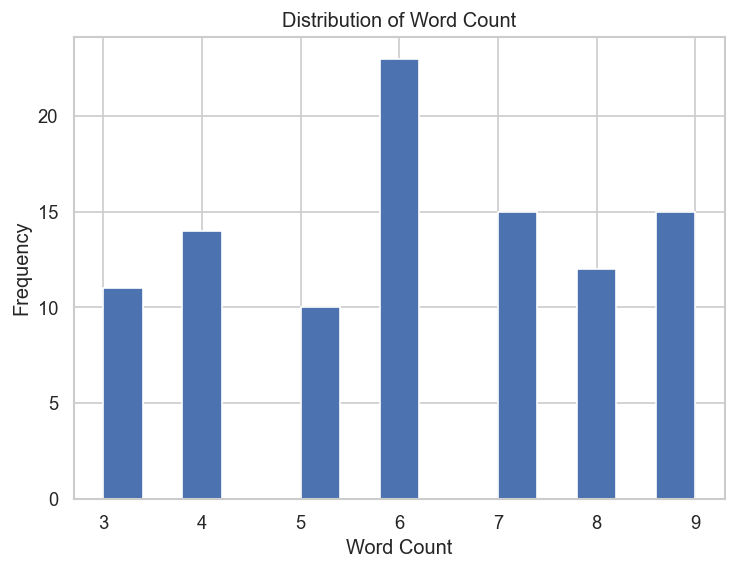

In [7]:
plt.figure(figsize=(7, 5))

df['word_count'].hist(bins=15)

plt.title("Distribution of Word Count")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.savefig("histogram_word_count.png")
plt.show()

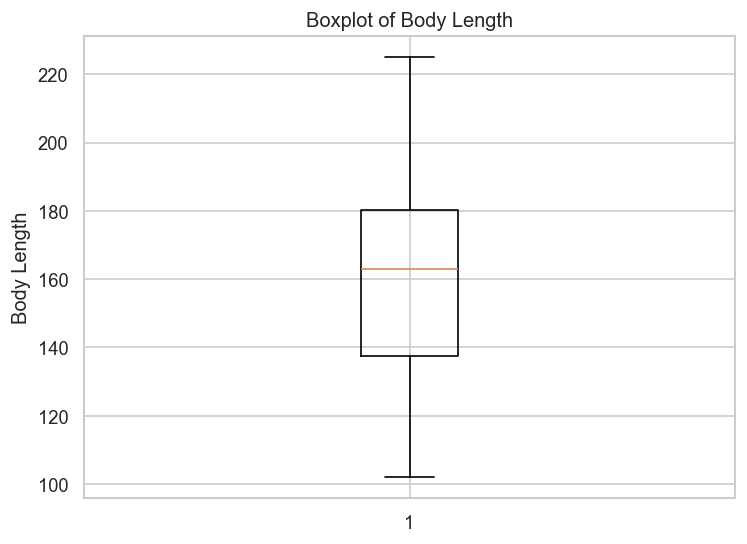

In [8]:
plt.figure(figsize=(7, 5))
plt.boxplot(df['body_length'])
plt.title("Boxplot of Body Length")
plt.ylabel("Body Length")
plt.savefig("boxplot_body_length.png")
plt.show()

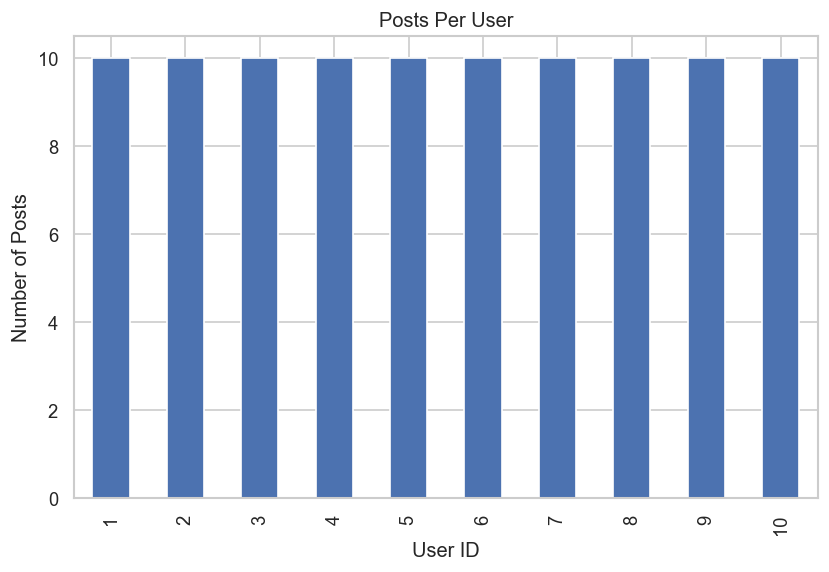

In [9]:
user_post_counts = df['userId'].value_counts()

plt.figure(figsize=(8, 5))
user_post_counts.plot(kind='bar')
plt.title("Posts Per User")
plt.xlabel("User ID")
plt.ylabel("Number of Posts")
plt.savefig("bar_chart_posts_per_user.png")
plt.show()

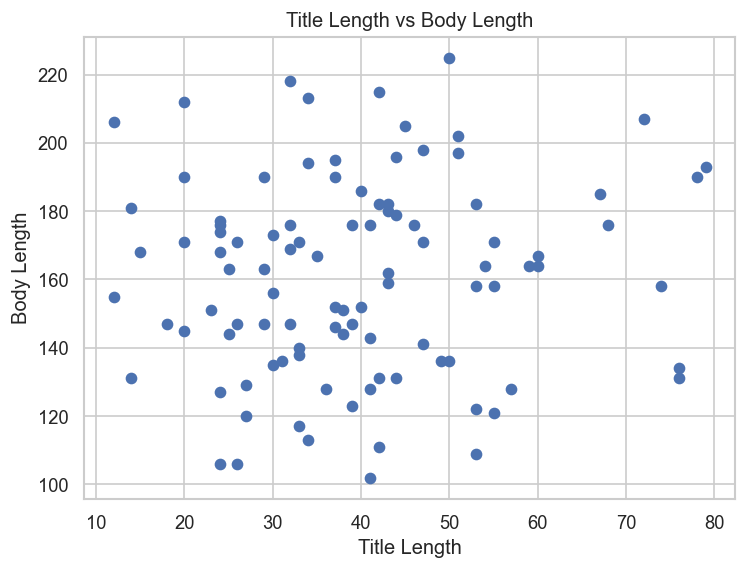

In [10]:
plt.figure(figsize=(7, 5))
plt.scatter(df['title_length'], df['body_length'])
plt.title("Title Length vs Body Length")
plt.xlabel("Title Length")
plt.ylabel("Body Length")
plt.savefig("scatter_title_vs_body.png")
plt.show()

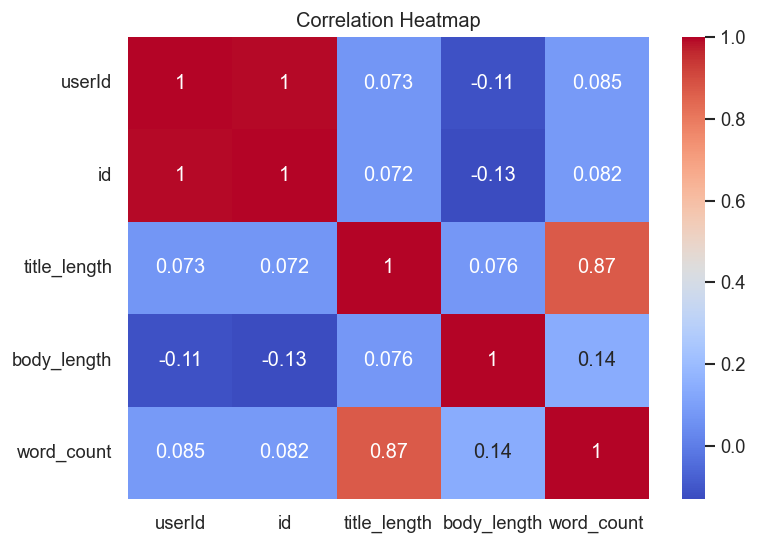

In [22]:
correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(7, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.savefig("heatmap.png")
plt.show()

## 6) Group comparison and bonus pairplot

In [12]:
group_summary = df.groupby('userId')[['word_count', 'body_length']].mean()

print("\nGroup Comparison:")
print(group_summary)


Group Comparison:
        word_count  body_length
userId                         
1              5.3        164.5
2              5.9        162.9
3              6.4        153.8
4              5.5        182.3
5              6.8        162.5
6              6.7        147.0
7              5.8        163.5
8              6.9        160.6
9              6.5        154.6
10             5.5        154.7


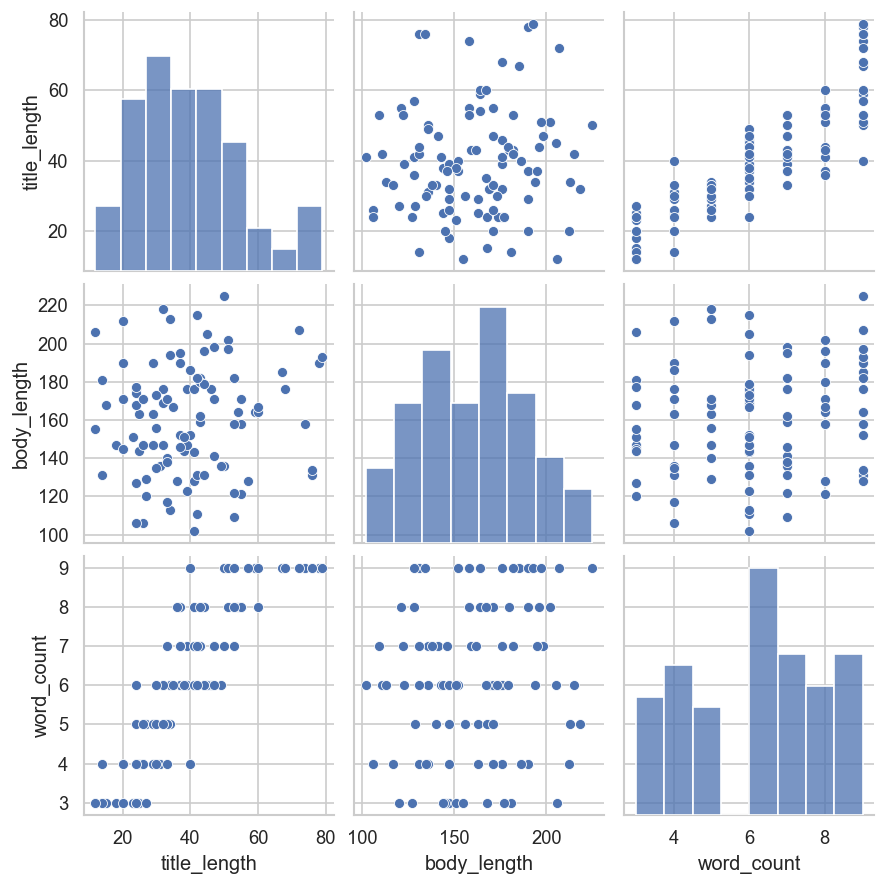

In [23]:
sns.pairplot(df[['title_length', 'body_length', 'word_count']])
plt.savefig('pairplot.png')
plt.show()

## 7) Save the cleaned dataset and write the report

In [14]:
df.to_csv('clean_posts.csv', index=False)

print("\nClean dataset saved successfully")

print("""

EDA REPORT

1. Dataset contains posts data fetched from a public API.

2. No major missing values were found after cleaning.

3. Word counts are mostly concentrated in lower ranges.

4. Some posts have unusually large body lengths.

5. Different users have posted almost equal numbers of posts.

6. Title length and body length show weak correlation.

7. Most distributions are slightly skewed.

8. Heatmap shows low to moderate correlations among variables.

9. Pairplot helps visualize relationships between numeric columns.

10. The most interesting finding is that longer titles do not always mean longer post bodies.

""")


Clean dataset saved successfully


EDA REPORT

1. Dataset contains posts data fetched from a public API.

2. No major missing values were found after cleaning.

3. Word counts are mostly concentrated in lower ranges.

4. Some posts have unusually large body lengths.

5. Different users have posted almost equal numbers of posts.

6. Title length and body length show weak correlation.

7. Most distributions are slightly skewed.

8. Heatmap shows low to moderate correlations among variables.

9. Pairplot helps visualize relationships between numeric columns.

10. The most interesting finding is that longer titles do not always mean longer post bodies.


